# **Value at Risk (VaR)**
### Cuantificando la Pérdida Máxima Esperada

El **Value at Risk (VaR)** es la métrica de riesgo más utilizada en la industria financiera. Responde a la pregunta:

> *"¿Cuál es la máxima pérdida esperada de una inversión, en un horizonte de tiempo determinado, con un nivel de confianza dado?"*

Por ejemplo, un **VaR diario al 95% de -3%** significa que, en condiciones normales de mercado, no se espera perder más del 3% del valor de la inversión en un día, el 95% de las veces.

En este notebook calculamos el VaR con tres metodologías distintas y las comparamos:

1. **VaR Histórico** (no paramétrico, basado en percentiles empíricos)
2. **VaR Paramétrico** (Varianza-Covarianza, asume normalidad)
3. **VaR por Simulación de Monte Carlo**

Además, calculamos el **Conditional VaR (CVaR / Expected Shortfall)** y hacemos un **backtesting** simple del modelo.

## Librerías usadas

In [1]:
# Manipulación de datos y análisis estadístico
import pandas as pd
import numpy as np
from scipy.stats import norm

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_palette("viridis")

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

%matplotlib inline

## Datos: Retornos del IBEX 35

Usamos la serie de retornos históricos del IBEX 35 ya calculada en [`Data/resultado.csv`](../Data/resultado.csv).

In [2]:
returns = pd.read_csv("../Data/resultado.csv").squeeze("columns")
returns = pd.to_numeric(returns, errors="coerce").dropna()
returns.name = "IBEX35"

print(f"Observaciones: {len(returns)}")
returns.describe()

Observaciones: 308


count    308.000000
mean       0.002020
std        0.058873
min       -0.247337
25%       -0.028273
50%       -0.000798
75%        0.034799
max        0.236152
Name: IBEX35, dtype: float64

### Distribución de los retornos

Antes de calcular el VaR, visualizamos la distribución empírica de los retornos frente a una distribución normal con la misma media y desviación estándar. Esto nos da una primera intuición de qué tan bien el supuesto de normalidad (necesario para el VaR paramétrico) se ajusta a los datos.

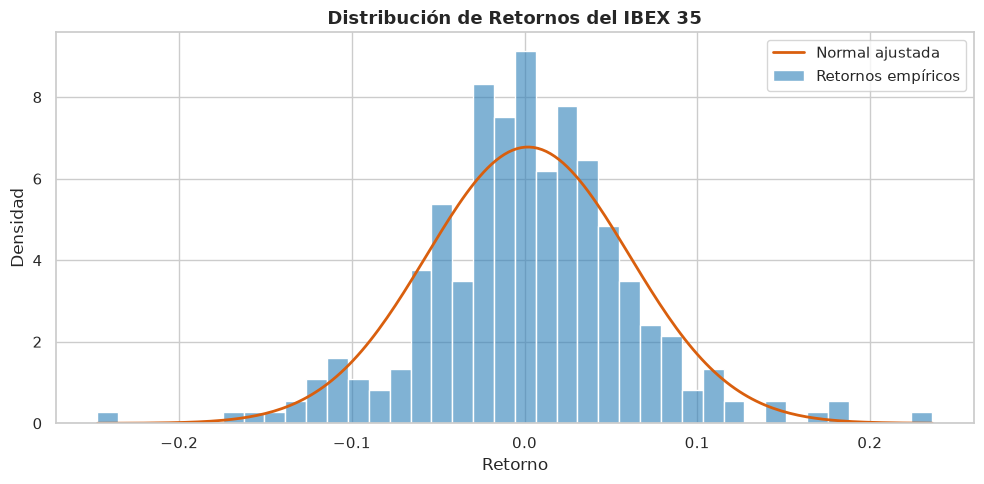

Media: 0.2020% | Volatilidad: 5.8873% | Skew: -0.01 | Kurtosis: 2.04


In [3]:
mu, sigma = returns.mean(), returns.std()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(returns, bins=40, stat="density", color="#2c7fb8", alpha=0.6, ax=ax, label="Retornos empíricos")

x = np.linspace(returns.min(), returns.max(), 200)
ax.plot(x, norm.pdf(x, mu, sigma), color="#d95f0e", lw=2, label="Normal ajustada")

ax.set_title("Distribución de Retornos del IBEX 35", fontsize=13, fontweight="bold")
ax.set_xlabel("Retorno")
ax.set_ylabel("Densidad")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Media: {mu:.4%} | Volatilidad: {sigma:.4%} | Skew: {returns.skew():.2f} | Kurtosis: {returns.kurt():.2f}")

## Nivel de Confianza y Horizonte

Fijamos los niveles de confianza estándar de la industria (95% y 99%) y trabajamos con el horizonte diario de la serie.

In [4]:
confidence_levels = [0.95, 0.99]
n_obs = len(returns)

## 1. VaR Histórico

Es el método más simple e intuitivo: no asume ninguna distribución, sino que usa directamente el percentil empírico de los retornos observados.

$$
\Large VaR_{\alpha}^{hist} = -\,\text{Percentil}_{(1-\alpha)}(retornos)
$$

In [5]:
def var_historico(returns, alpha):
    return -np.percentile(returns, (1 - alpha) * 100)

var_hist = {a: var_historico(returns, a) for a in confidence_levels}

for a, v in var_hist.items():
    print(f"VaR Histórico ({a:.0%}): {v:.4%}")

VaR Histórico (95%): 10.1935%
VaR Histórico (99%): 14.9263%


## 2. VaR Paramétrico (Varianza-Covarianza)

Asume que los retornos siguen una distribución normal $N(\mu, \sigma)$. El VaR se obtiene directamente del cuantil de la normal:

$$
\Large VaR_{\alpha}^{param} = -\left(\mu + \sigma \cdot z_{1-\alpha}\right)
$$

donde $z_{1-\alpha}$ es el cuantil de la normal estándar.

In [6]:
def var_parametrico(mu, sigma, alpha):
    z = norm.ppf(1 - alpha)
    return -(mu + sigma * z)

var_param = {a: var_parametrico(mu, sigma, a) for a in confidence_levels}

for a, v in var_param.items():
    print(f"VaR Paramétrico ({a:.0%}): {v:.4%}")

VaR Paramétrico (95%): 9.4817%
VaR Paramétrico (99%): 13.4939%


## 3. VaR por Simulación de Monte Carlo

Simulamos miles de escenarios de retornos futuros a partir de la distribución normal ajustada ($\mu$, $\sigma$) y tomamos el percentil empírico de esas simulaciones. Con muchas simulaciones converge al VaR paramétrico, pero el enfoque se puede extender fácilmente a distribuciones no normales o a carteras con varios activos.

In [7]:
np.random.seed(42)
n_sims = 100_000

sim_returns = np.random.normal(mu, sigma, n_sims)

def var_montecarlo(sim_returns, alpha):
    return -np.percentile(sim_returns, (1 - alpha) * 100)

var_mc = {a: var_montecarlo(sim_returns, a) for a in confidence_levels}

for a, v in var_mc.items():
    print(f"VaR Monte Carlo ({a:.0%}): {v:.4%}")

VaR Monte Carlo (95%): 9.4737%
VaR Monte Carlo (99%): 13.5428%


## Comparación Visual de los 3 Métodos

Visualizamos el VaR al 95% de cada metodología sobre la distribución de retornos, y comparamos los tres métodos en ambos niveles de confianza.

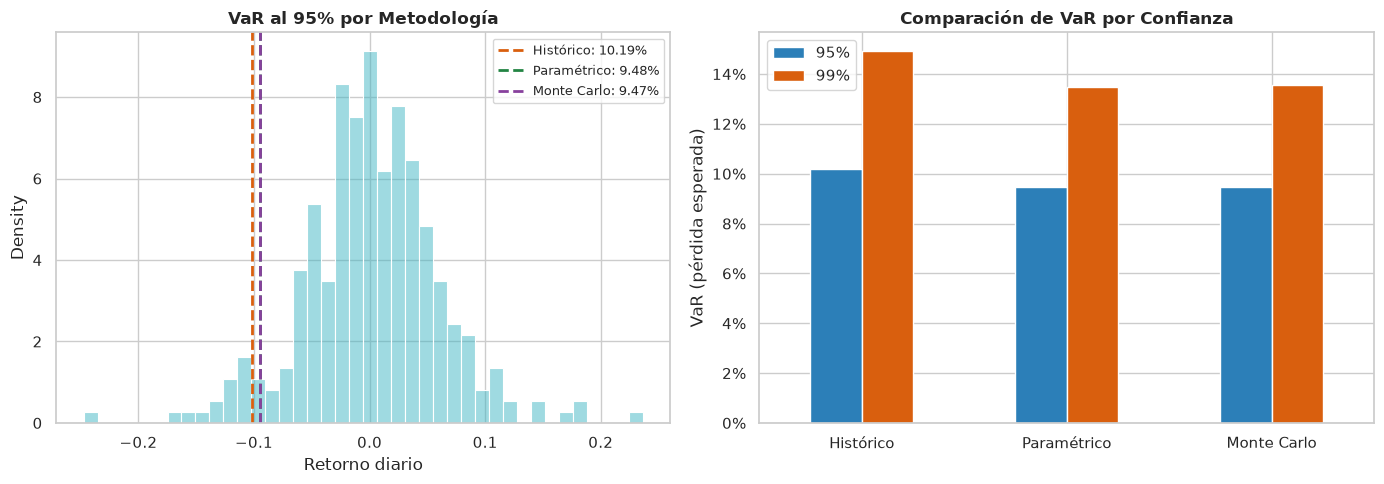

,95%,99%
Histórico,10.19%,14.93%
Paramétrico,9.48%,13.49%
Monte Carlo,9.47%,13.54%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: VaR 95% sobre la distribución ---
ax = axes[0]
sns.histplot(returns, bins=40, stat="density", color="#41b6c4", alpha=0.5, ax=ax)
colors = {"Histórico": "#d95f0e", "Paramétrico": "#238443", "Monte Carlo": "#88419d"}
for label, val in zip(colors, [var_hist[0.95], var_param[0.95], var_mc[0.95]]):
    ax.axvline(-val, color=colors[label], lw=2, ls="--", label=f"{label}: {val:.2%}")
ax.set_title("VaR al 95% por Metodología", fontweight="bold")
ax.set_xlabel("Retorno diario")
ax.legend(fontsize=9)

# --- Panel 2: comparación de barras ---
ax = axes[1]
methods = ["Histórico", "Paramétrico", "Monte Carlo"]
df_var = pd.DataFrame({
    "95%": [var_hist[0.95], var_param[0.95], var_mc[0.95]],
    "99%": [var_hist[0.99], var_param[0.99], var_mc[0.99]],
}, index=methods)
df_var.plot(kind="bar", ax=ax, color=["#2c7fb8", "#d95f0e"], rot=0)
ax.set_title("Comparación de VaR por Confianza", fontweight="bold")
ax.set_ylabel("VaR (pérdida esperada)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

df_var.style.format("{:.2%}")

## Conditional VaR (CVaR / Expected Shortfall)

El VaR responde "¿cuánto puedo perder como máximo con tal confianza?", pero no dice **cuánto** se pierde en el peor de los casos (cuando se supera el VaR). El **CVaR** (o Expected Shortfall) es el promedio de las pérdidas que exceden el VaR:

$$
\Large CVaR_{\alpha} = -\,\mathbb{E}\left[r \mid r \le -VaR_{\alpha}\right]
$$

In [9]:
def cvar_historico(returns, alpha):
    var = var_historico(returns, alpha)
    tail = returns[returns <= -var]
    return -tail.mean()

cvar_hist = {a: cvar_historico(returns, a) for a in confidence_levels}

resumen = pd.DataFrame({
    "VaR Histórico": var_hist,
    "CVaR (Expected Shortfall)": cvar_hist,
})
resumen.index.name = "Confianza"
resumen.style.format("{:.2%}")

,VaR Histórico,CVaR (Expected Shortfall)
Confianza,,
0.950000,10.19%,13.20%
0.990000,14.93%,18.14%


## Backtesting del VaR

Un modelo de VaR es confiable si el número de veces que la pérdida real supera el VaR estimado (**excepciones**) es consistente con el nivel de confianza elegido. Por ejemplo, con un VaR al 95%, esperamos que las pérdidas lo superen aproximadamente el 5% de las veces.

In [10]:
backtest = []
for a in confidence_levels:
    excepciones = (returns < -var_hist[a]).sum()
    tasa_esperada = 1 - a
    tasa_observada = excepciones / n_obs
    backtest.append({
        "Confianza": f"{a:.0%}",
        "Excepciones observadas": excepciones,
        "Tasa esperada": tasa_esperada,
        "Tasa observada": tasa_observada,
    })

backtest_df = pd.DataFrame(backtest).set_index("Confianza")
backtest_df.style.format({"Tasa esperada": "{:.2%}", "Tasa observada": "{:.2%}"})

,Excepciones observadas,Tasa esperada,Tasa observada
Confianza,,,
95%,16,5.00%,5.19%
99%,4,1.00%,1.30%


## Conclusiones

- El **VaR Histórico** y el **VaR Monte Carlo** arrojan resultados muy similares, lo cual es esperable dado que la simulación se basó en un ajuste normal de los mismos datos.
- El **VaR Paramétrico** puede subestimar o sobreestimar el riesgo real cuando la distribución de retornos tiene colas más pesadas que la normal (kurtosis alta) o asimetría — algo común en series financieras.
- El **CVaR** siempre es mayor (en magnitud) que el VaR al mismo nivel de confianza, ya que captura la severidad esperada de las pérdidas extremas, no solo su frecuencia.
- El **backtesting** permite validar si el modelo es adecuado: si la tasa observada de excepciones se aleja mucho de la esperada, el modelo de VaR debería recalibrarse (por ejemplo, usando una distribución con colas más pesadas o una ventana de estimación distinta).